# ML Theory 8


In [79]:
!pip install ucimlrepo

In [80]:
from sklearn.metrics import pairwise_distances

dist_matrix = pairwise_distances(X, metric='euclidean')

In [81]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
# print(iris.metadata)

# variable information
# print(iris.variables)

X.shape


(150, 4)

In [82]:
print(dist_matrix[:3, :3])

[[0.         0.53851648 0.50990195]
 [0.53851648 0.         0.3       ]
 [0.50990195 0.3        0.        ]]


In [83]:
edges = []

n = dist_matrix.shape[0]

for i in range(n):
    for j in range(i + 1, n):
        weight = dist_matrix[i][j]
        edges.append((i, j, weight))

print(edges[:8])

[(0, 1, np.float64(0.5385164807134628)), (0, 2, np.float64(0.5099019513592765)), (0, 3, np.float64(0.6480740698407873)), (0, 4, np.float64(0.14142135623729543)), (0, 5, np.float64(0.6164414002968998)), (0, 6, np.float64(0.5196152422706594)), (0, 7, np.float64(0.173205080756891)), (0, 8, np.float64(0.9219544457292856))]


In [84]:
edges = sorted(edges, key=lambda x: x[2])

In [85]:
import numpy as np

# -------------------------------
# UNION-FIND (Disjoint Set)
# -------------------------------

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        # Path Compression
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        root_x = self.find(x)
        root_y = self.find(y)

        if root_x != root_y:
            self.parent[root_y] = root_x
            return True   # union happened
        return False      # already connected


# -------------------------------
# KRUSKAL MST
# -------------------------------

def kruskal_mst(edges, n):
    """
    edges: list of (u, v, weight)
    n: number of nodes
    """
    uf = UnionFind(n)
    mst = []

    # Sort edges by weight
    edges = sorted(edges, key=lambda x: x[2])

    for u, v, w in edges:
        # If u and v are in different components
        if uf.union(u, v):
            mst.append((u, v, w))

        # Stop when MST has (n-1) edges
        if len(mst) == n - 1:
            break

    return mst

In [86]:
n = dist_matrix.shape[0]

mst = kruskal_mst(edges, n)

print(len(mst))   # should be n-1 (149 for Iris)

149


In [87]:
mst_sorted = sorted(mst, key=lambda item: item[2], reverse=True)

In [88]:
k = 3   # or from argument

edges_to_keep = mst_sorted[k-1:]   # remove top (k-1)

In [89]:
uf = UnionFind(n)

for u, v, w in edges_to_keep:
    uf.union(u, v)

In [90]:
clusters = {}

for node in range(n):
    root = uf.find(node)

    if root not in clusters:
        clusters[root] = len(clusters)

In [96]:
mst_labels = [clusters[uf.find(i)] for i in range(n)]

In [97]:
print(set(mst_labels))

{0, 1, 2}


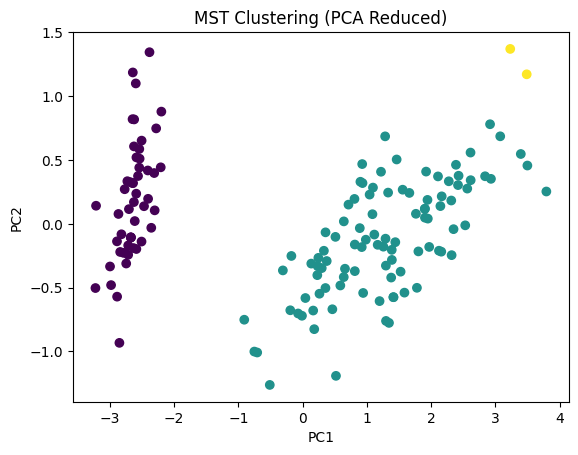

In [98]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Plot MST clusters
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=mst_labels)
plt.title("MST Clustering (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [99]:
from sklearn.cluster import KMeans

k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

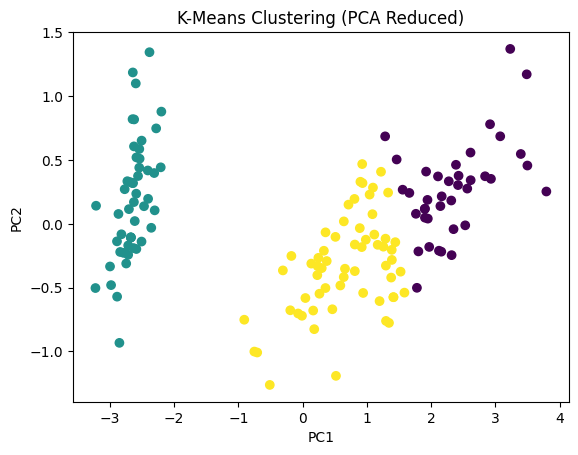

In [105]:
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [110]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

y = y.values.flatten()

# Internal
print("Silhouette MST:", silhouette_score(X, mst_labels))
print("Silhouette KMeans:", silhouette_score(X, kmeans_labels))

# External
print("ARI MST:", adjusted_rand_score(y, mst_labels))
print("ARI KMeans:", adjusted_rand_score(y, kmeans_labels))

print("NMI MST:", normalized_mutual_info_score(y, mst_labels))
print("NMI KMeans:", normalized_mutual_info_score(y, kmeans_labels))

Silhouette MST: 0.5118387098922373
Silhouette KMeans: 0.5509643746707443
ARI MST: 0.5637510205230709
ARI KMeans: 0.7163421126838476
NMI MST: 0.7174643320814476
NMI KMeans: 0.7419116631817836


The experimental results show that K-Means clustering outperforms MST-based clustering on the Iris dataset. K-Means achieved higher silhouette score, ARI, and NMI, indicating better cluster compactness and stronger alignment with ground truth labels. This is because the Iris dataset contains relatively well-separated and spherical clusters, which align with the assumptions of K-Means.

On the other hand, MST-based clustering relies on graph connectivity and is capable of capturing non-spherical cluster structures. However, it is sensitive to local variations and edge weights, which can lead to suboptimal cluster separation in structured datasets like Iris. Despite this, MST still achieved reasonably good NMI, indicating that it captures meaningful relationships in the data.

Overall, K-Means is more suitable for datasets with compact and well-separated clusters, while MST-based clustering is more flexible for irregular and non-spherical cluster structures.

## Prim's algo

In [114]:
import heapq

# -------------------------------
# PRIM'S MST
# -------------------------------
def prim_mst(dist_matrix):
    n = dist_matrix.shape[0]

    visited = [False] * n
    mst = []

    # (weight, from_node, to_node)
    min_heap = [(0, -1, 0)]  # start from node 0

    while min_heap and len(mst) < n:
        weight, u, v = heapq.heappop(min_heap)

        if visited[v]:
            continue

        visited[v] = True

        if u != -1:
            mst.append((u, v, weight))

        # push neighbors
        for to in range(n):
            if not visited[to]:
                heapq.heappush(min_heap, (dist_matrix[v][to], v, to))

    return mst


# -------------------------------
# UNION-FIND
# -------------------------------
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # path compression
        return self.parent[x]

    def union(self, x, y):
        root_x = self.find(x)
        root_y = self.find(y)

        if root_x != root_y:
            self.parent[root_y] = root_x


# -------------------------------
# MST → CLUSTERS
# -------------------------------
def mst_to_clusters(mst, n, k):
    # Sort edges by weight (descending)
    mst_sorted = sorted(mst, key=lambda x: x[2], reverse=True)

    # Remove (k-1) largest edges
    edges_to_keep = mst_sorted[k-1:]

    # Rebuild components
    uf = UnionFind(n)

    for u, v, w in edges_to_keep:
        uf.union(u, v)

    # Assign cluster labels
    clusters = {}
    labels = []

    for i in range(n):
        root = uf.find(i)

        if root not in clusters:
            clusters[root] = len(clusters)

        labels.append(clusters[root])

    return labels


# -------------------------------
# USAGE
# -------------------------------
k = 3
n = dist_matrix.shape[0]

mst_prim = prim_mst(dist_matrix)
prim_labels = mst_to_clusters(mst_prim, n, k)

print("Number of clusters:", len(set(prim_labels)))
# print("Sample labels:", prim_labels[:10])

Number of clusters: 3


In [117]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Internal
print("Silhouette Prims:", silhouette_score(X, prim_labels))
print("Silhouette KMeans:", silhouette_score(X, kmeans_labels))

# External
print("ARI Prims:", adjusted_rand_score(y, prim_labels))
print("ARI KMeans:", adjusted_rand_score(y, kmeans_labels))

print("NMI Prims:", normalized_mutual_info_score(y, prim_labels))
print("NMI KMeans:", normalized_mutual_info_score(y, kmeans_labels))

Silhouette Prims: 0.5118387098922373
Silhouette KMeans: 0.5509643746707443
ARI Prims: 0.5637510205230709
ARI KMeans: 0.7163421126838476
NMI Prims: 0.7174643320814476
NMI KMeans: 0.7419116631817836


Minimum Spanning Tree (MST) based clustering works by constructing a fully connected graph using pairwise distances and then extracting the MST, which preserves the most significant structural relationships between data points. By removing the (k−1) largest edges, the tree is partitioned into k connected components, which form clusters. This method does not assume any specific cluster shape and can capture non-spherical and irregular cluster structures effectively.

In contrast, K-Means clustering partitions data based on distance to centroids and assumes spherical cluster shapes. While K-Means is computationally efficient and works well for compact and well-separated clusters, it struggles with irregular or elongated clusters. MST-based clustering is more flexible in capturing intrinsic data geometry but can be sensitive to noise and outliers. The comparison using silhouette score helps evaluate the quality of clustering produced by both methods.

### Why MST based clustering captures non-spherical cluster ?
Minimum Spanning Tree (MST)–based clustering captures non-spherical clusters because it relies on connectivity between nearby data points rather than distance from a central centroid. By constructing a graph where edges represent pairwise distances, MST preserves the intrinsic structure of the data. Unlike K-Means, which assumes clusters are spherical and centered around a mean, MST does not impose any shape constraints.

When the (k−1) largest edges are removed, the tree splits at weak connections, naturally separating dense regions regardless of their shape. This allows MST to follow elongated, curved, or irregular patterns in the data. As a result, clusters can form along complex manifolds or chains of points. MST clustering is therefore more flexible and effective in detecting non-linear and non-convex cluster structures compared to centroid-based methods.